# \[Kaggle\] Spam mail

SEOYEON CHOI  
2025-11-24

[data](https://www.kaggle.com/datasets/somesh24/spambase)

-   SPAM E-mail Database
    -   The “spam” concept is diverse: advertisements for
        products/websites, make money fast schemes, chain letters,
        pornography… Our collection of spam e-mails came from our
        postmaster and individuals who had filed spam. Our collection of
        non-spam e-mails came from filed work and personal e-mails, and
        hence the word ‘george’ and the area code ‘650’ are indicators
        of non-spam. These are useful when constructing a personalized
        spam filter. One would either have to blind such non-spam
        indicators or get a very wide collection of non-spam to generate
        a general purpose spam filter.
-   Attribute Information:
    -   The last column denotes whether the e-mail was considered
        spam (1) or not (0), i.e. unsolicited commercial e-mail. Most of
        the attributes indicate whether a particular word or character
        was frequently occurring in the e-mail. The run-length
        attributes (55-57) measure the length of sequences of
        consecutive capital letters.
    -   For the statistical measures of each attribute, see the end of
        this file. Here are the definitions of the attributes:
    -   48 continuous real \[0,100\] attributes of type word_freq_WORD =
        percentage of words in the e-mail that match WORD, i.e. 100 \*
        (number of times the WORD appears in the e-mail) / total number
        of words in e-mail. A “word” in this case is any string of
        alphanumeric characters bounded by non-alphanumeric characters
        or end-of-string.
    -   6 continuous real \[0,100\] attributes of type char_freq_CHAR =
        percentage of characters in the e-mail that match CHAR, i.e. 100
        \* (number of CHAR occurrences) / total characters in e-mail
    -   1 continuous real \[1,…\] attribute of type
        capital_run_length_average = average length of uninterrupted
        sequences of capital letters
    -   1 continuous integer \[1,…\] attribute of type
        capital_run_length_longest = length of longest uninterrupted
        sequence of capital letters
    -   1 continuous integer \[1,…\] attribute of type
        capital_run_length_total = sum of length of uninterrupted
        sequences of capital letters = total number of capital letters
        in the e-mail
    -   1 nominal {0,1} class attribute of type spam = denotes whether
        the e-mail was considered spam (1) or not (0), i.e. unsolicited
        commercial e-mail.

In [88]:
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
df = pd.read_csv('../../../delete/spambase_csv.csv')

In [5]:
df.head()

5 rows × 58 columns

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

Text(0.5, 1.0, 'Distribution of Spam Emails')

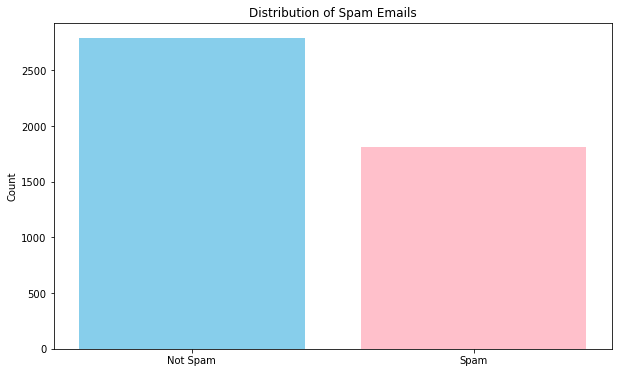

In [37]:
plt.figure(figsize=(10,6))
plt.bar(df['class'].value_counts().sort_index().index,df['class'].value_counts().sort_index().values, color=['skyblue','pink'])
plt.xticks([0,1],['Not Spam','Spam'],fontsize=10)
plt.ylabel('Count')
plt.title('Distribution of Spam Emails')

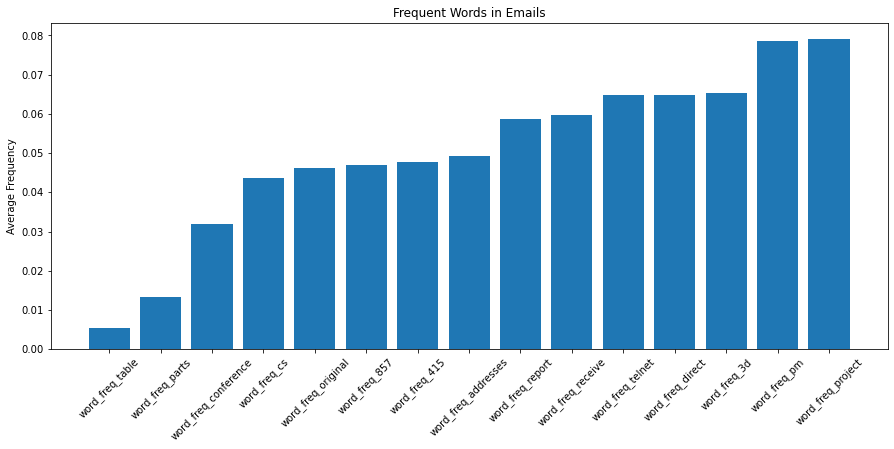

In [87]:
plt.figure(figsize=(15,6))
plt.bar(df[[col for col in df.columns if col.startswith("word_freq")]].mean().sort_values().head(15).index,\
       df[[col for col in df.columns if col.startswith("word_freq")]].mean().sort_values().head(15).values)
plt.title('Frequent Words in Emails')
plt.ylabel('Average Frequency')
plt.xticks(rotation=45);

In [94]:
df

4601 rows × 58 columns

In [93]:
fig = px.scatter(
    df,
    x="word_freq_free",
    y="word_freq_money",
    color=df["class"].astype(str),
    title="Free vs Money Frequency",
    labels={"class": "Spam"},
    width=1000,
    height=500
)
fig.show()